In [2]:
import sqlite3
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_DIR = Path("../data/raw")

df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")
df_v = pd.read_csv(DATA_DIR / "vitalPeriodic.csv")
df_h = pd.read_csv(DATA_DIR / "hospital.csv")
df_d = pd.read_csv(DATA_DIR / "diagnosis.csv")

In [ ]:
# Calcola entrambi i conteggi
righe_totali = df_d["diagnosisstring"].value_counts().head(10)
pazienti_unici = df_d.groupby("diagnosisstring")["patientunitstayid"].nunique()

# Allinea sulle stesse diagnosi (top 10 per righe totali)
top10 = pd.DataFrame({
    "righe_totali": righe_totali,
    "pazienti_unici": pazienti_unici
}).dropna().head(10).sort_values("pazienti_unici", ascending=True)

# Abbrevia le etichette
labels = [d.split("|")[-1] for d in top10.index]

fig, ax = plt.subplots(figsize=(13, 7))

y = range(len(top10))
height = 0.35

bars1 = ax.barh([i + height/2 for i in y], top10["righe_totali"], height=height, label="Righe totali", color="steelblue", alpha=0.85)
bars2 = ax.barh([i - height/2 for i in y], top10["pazienti_unici"], height=height, label="Pazienti unici", color="coral", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, str(int(bar.get_width())), va="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, str(int(bar.get_width())), va="center", fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Conteggio", fontsize=11)
ax.set_title("Top 10 diagnosi — Righe totali vs Pazienti unici", fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
pazienti_arf = df_d[df_d["diagnosisstring"] == 
                    "pulmonary|respiratory failure|acute respiratory failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con ARF: {len(pazienti_arf)}")

# Join con trattamenti
trattamenti_arf = df_t[df_t["patientunitstayid"].isin(pazienti_arf)]

print(f"Trattamenti totali: {len(trattamenti_arf)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf["treatmentstring"].value_counts().head(20))

In [ ]:
pazienti_arf1 = df_d[df_d["diagnosisstring"] == 
                    "renal|disorder of kidney|acute renal failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con arf1: {len(pazienti_arf1)}")

# Join con trattamenti
trattamenti_arf1 = df_t[df_t["patientunitstayid"].isin(pazienti_arf1)]

print(f"Trattamenti totali: {len(trattamenti_arf1)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf1["treatmentstring"].value_counts().head(20))

In [ ]:
df_counts = pd.DataFrame({
    'righe_totali': df_t['treatmentstring'].value_counts(),
    'pazienti_unici': df_t.groupby('treatmentstring')['patientunitstayid'].nunique()
}).sort_values('pazienti_unici', ascending=True).tail(20)  # top 20

# Accorcia le label (prendi solo l'ultimo livello della gerarchia)
df_counts.index = df_counts.index.str.split('|').str[-1]

fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(df_counts))
height = 0.35

bars1 = ax.barh(
    [i + height/2 for i in y],   #posizione delle barre
    df_counts['righe_totali'],
    height=height,
    label='Righe totali',
    color='steelblue',
    alpha=0.85
)
bars2 = ax.barh(
    [i - height/2 for i in y],
    df_counts['pazienti_unici'],
    height=height,
    label='Pazienti unici',
    color='coral',
    alpha=0.85
)

# Etichette valori
for bar in bars1:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,   #posizione testo centrato e a destra del wigdht
            f'{int(bar.get_width())}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_counts.index, fontsize=9)
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_title('Top 20 trattamenti — Righe totali vs Pazienti unici', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Calcola metriche per ospedale
hospital_stats = df_p.groupby('hospitalid').agg(
    stay_totali=('patientunitstayid', 'count'),
    pazienti_unici=('uniquepid', 'nunique'),
    tasso_mortalita=('hospitaldischargestatus', lambda x: (x == 'Expired').mean())
).round(3).reset_index()

# Unisci con le info ospedaliere
hospital_stats = hospital_stats.merge(
    df_h[['hospitalid', 'numbedscategory', 'teachingstatus', 'region']],
    on='hospitalid',
    how='left'
)

# Ordina per stay totali
hospital_stats = hospital_stats.sort_values('stay_totali', ascending=False)

print(f"Ospedali totali: {len(hospital_stats)}")
print(f"Tasso mortalità medio: {hospital_stats['tasso_mortalita'].mean():.3f}")
print()
print(hospital_stats.to_string(index=False))




In [ ]:
morti = df_p["unitdischargestatus"].value_counts()
print(morti)

# Percentuale
print(f"\nMorti: {(df_p['unitdischargestatus'] == 'Expired').sum()}")
print(f"Totale pazienti: {len(df_p)}")
print(f"Mortalità: {(df_p['unitdischargestatus'] == 'Expired').mean()*100:.1f}%")

In [ ]:
# Crea colonna ventilato
ventilati = df_t[df_t["treatmentstring"].str.contains(
    "mechanical ventilation", case=False, na=False
)]["patientunitstayid"].unique()

df_p["ventilato"] = df_p["patientunitstayid"].isin(ventilati).astype(int)

# Distribuzione morti per gruppo
dist = df_p.groupby("ventilato")["unitdischargestatus"].value_counts()
print(dist)

# Mortalità % per gruppo
print("\nMortalità per gruppo:")
print(df_p.groupby("ventilato")["unitdischargestatus"]
      .apply(lambda x: (x == "Expired").mean() * 100)
      .rename({0: "Non ventilati", 1: "Ventilati"}))

In [ ]:
# Pulizia età
df_p['age_clean'] = pd.to_numeric(df_p['age'], errors='coerce')
df_p.loc[df_p['age'] == '> 89', 'age_clean'] = 90

# Fasce età
bins = [0, 18, 30, 45, 60, 75, 90, 120]
labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75-89', '≥90']
df_p['fascia_eta'] = pd.cut(df_p['age_clean'], bins=bins, labels=labels, right=False)
df_p['deceduto'] = (df_p['hospitaldischargestatus'] == 'Expired').astype(int)

# ============================================================
# FIGURA 1 — Età e Mortalità per fascia
# ============================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Distribuzione Età e Mortalità — Popolazione eICU',
              fontsize=13, fontweight='bold')

# Grafico 1a — Distribuzione età con n e percentuale
counts = df_p['fascia_eta'].value_counts().sort_index()
totale = len(df_p)

bars = axes1[0].bar(counts.index, counts.values, color='steelblue',
                    alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes1[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                  f'{int(val)}\n({val/totale*100:.1f}%)',
                  ha='center', va='bottom', fontsize=8)
axes1[0].set_title("Distribuzione per fascia d'età", fontweight='bold')
axes1[0].set_xlabel("Fascia d'età")
axes1[0].set_ylabel('N pazienti')
axes1[0].spines['top'].set_visible(False)
axes1[0].spines['right'].set_visible(False)

# Grafico 1b — Mortalità per fascia età (n morti + % sulla fascia)
mortalita_eta = df_p.groupby('fascia_eta', observed=True)['deceduto'].agg(['sum', 'mean'])

bars4 = axes1[1].bar(mortalita_eta.index, mortalita_eta['mean'] * 100,
                     color='salmon', alpha=0.85, edgecolor='white')
for bar, (n_morti, perc) in zip(bars4, zip(mortalita_eta['sum'], mortalita_eta['mean'] * 100)):
    axes1[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{int(n_morti)}\n({perc:.1f}%)',
                  ha='center', va='bottom', fontsize=8)
axes1[1].set_title("Tasso di mortalità per fascia d'età", fontweight='bold')
axes1[1].set_xlabel("Fascia d'età")
axes1[1].set_ylabel('Mortalità (%)')
axes1[1].spines['top'].set_visible(False)
axes1[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eta_mortalita.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 — Sesso ed Etnia
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Distribuzione Sesso ed Etnia — Popolazione eICU',
              fontsize=13, fontweight='bold')

# Grafico 2a — Torta sesso
sesso = df_p['gender'].value_counts()
colori = ['steelblue', 'coral', 'lightgray']
wedges, texts, autotexts = axes2[0].pie(
    sesso.values, labels=sesso.index, autopct='%1.1f%%',
    colors=colori[:len(sesso)], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(10)
axes2[0].set_title('Distribuzione per sesso', fontweight='bold')

# Grafico 2b — Etnia
etnia = df_p['ethnicity'].value_counts()
colors_etnia = plt.cm.Set2(np.linspace(0, 1, len(etnia)))
bars3 = axes2[1].barh(etnia.index, etnia.values,
                      color=colors_etnia, alpha=0.85, edgecolor='white')
for bar in bars3:
    axes2[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                  str(int(bar.get_width())), va='center', fontsize=8)
axes2[1].set_title('Distribuzione per etnia', fontweight='bold')
axes2[1].set_xlabel('N pazienti')
axes2[1].spines['top'].set_visible(False)
axes2[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sesso_etnia.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 — Torta mortalità
# ============================================================
fig3, ax = plt.subplots(figsize=(6, 6))

stato = df_p['hospitaldischargestatus'].value_counts()
colori = ['steelblue', 'salmon', 'lightgray']
wedges, texts, autotexts = ax.pie(
    stato.values,
    labels=stato.index,
    autopct='%1.1f%%',
    colors=colori[:len(stato)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(11)

ax.set_title('Stato alla dimissione ospedaliera', fontweight='bold', fontsize=13)
labels_leg = [f"{idx} (n={val})" for idx, val in zip(stato.index, stato.values)]
ax.legend(wedges, labels_leg, loc="lower center", fontsize=9)

plt.tight_layout()
plt.savefig('mortalita_torta.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STATISTICHE TESTUALI
# ============================================================
print(f"Età media: {df_p['age_clean'].mean():.1f} anni")
print(f"Età mediana: {df_p['age_clean'].median():.1f} anni")
print(f"\nTasso mortalità ospedaliera: {df_p['deceduto'].mean()*100:.2f}%")
print("\n--- SESSO ---")
print(df_p['gender'].value_counts())
print("\n--- ETNIA ---")
print(df_p['ethnicity'].value_counts())

In [ ]:
#confrontre la distribuzione fra i vari trattamenti "ventilation"

# Filtra tutti i trattamenti che contengono "ventilation"
ventilation_treatments = df_t[df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)]

# Conta le occorrenze
counts = ventilation_treatments["treatmentstring"].value_counts()

# Separa il principale dagli altri
main = "pulmonary|ventilation and oxygenation|mechanical ventilation"
main_count = counts.get(main, 0)
others = counts.drop(main, errors="ignore")

# Combina per il plot
plot_data = pd.concat([pd.Series({main: main_count}), others])

# Abbrevia le etichette per leggibilità
labels = [t.split("|")[-1] if "|" in t else t for t in plot_data.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c"] + ["#3498db"] * len(others)
bars = ax.barh(labels, plot_data.values, color=colors)

# Aggiungi i valori sulle barre
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Conteggio")
ax.set_title("Distribuzione trattamenti con 'ventilation'\n(rosso = mechanical ventilation)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()



In [ ]:
mask = df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)
total = mask.sum()
print(f"Trattamenti con ventilazione: {total}")

#unici per pazienti
total_pazienti = df_t[mask]["patientunitstayid"].nunique()
print(f"Pazienti con ventilazione: {total_pazienti}")



In [ ]:
top5_diagnosi = df_d["diagnosisstring"].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, diagnosi in enumerate(top5_diagnosi):
    pazienti = df_d[df_d["diagnosisstring"] == diagnosi]["patientunitstayid"].unique()
    trattamenti = df_t[df_t["patientunitstayid"].isin(pazienti)]["treatmentstring"].value_counts().head(8)
    
    # Abbrevia etichette
    labels = [t.split("|")[-1] for t in trattamenti.index]
    label_diagnosi = diagnosi.split("|")[-1]
    
    ax = axes[i]
    bars = ax.barh(labels, trattamenti.values, color="steelblue")
    
    for bar, val in zip(bars, trattamenti.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=8)
    
    ax.set_title(f"{label_diagnosi}\n(n={len(pazienti)} pazienti)", 
                 fontweight="bold", fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

# Nascondi subplot vuoto
axes[-1].set_visible(False)

fig.suptitle("Top 8 trattamenti per le 5 diagnosi più frequenti", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
DATA_DIR = Path("../data/raw")
df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")

# Definisci trattamento A
ventilati = df_t[
    df_t["treatmentstring"].str.contains("mechanical ventilation", case=False, na=False) &
    (df_t["treatmentoffset"] <= 1440)
]["patientunitstayid"].unique()

df_p["A"] = df_p["patientunitstayid"].isin(ventilati).astype(int)
df_p["Y"] = (df_p["unitdischargestatus"] == "Expired").astype(int)

df_analytical = df_p.copy()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Timing VM nelle prime 24h
vm_times = df_t[
    df_t["treatmentstring"].str.contains("mechanical ventilation", case=False, na=False) &
    (df_t["treatmentoffset"].between(0, 1440))
]["treatmentoffset"] / 60

axes[0].hist(vm_times, bins=24, color="tomato", edgecolor="white")
axes[0].set_xlabel("Ore dall'ingresso in ICU")
axes[0].set_ylabel("Frequenza")
axes[0].set_title("Timing VM nelle prime 24h", fontweight="bold")

# 2. Ventilati vs Non ventilati
gruppi = df_p["A"].value_counts()
bars = axes[1].bar(["Non ventilati (A=0)", "Ventilati (A=1)"],
                   gruppi.values, color=["steelblue", "tomato"])
for bar, val in zip(bars, gruppi.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"n={val}\n({val/len(df_p)*100:.1f}%)",
                 ha="center", fontweight="bold")
axes[1].set_ylabel("Numero pazienti")
axes[1].set_title("Ventilati vs Non Ventilati", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_ventilazione.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
missing = df_p.isnull().sum()
missing_pct = df_p.isnull().mean() * 100

missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct
}).sort_values('pct_missing', ascending=False)

print(missing_df[missing_df['n_missing'] > 0])

In [ ]:
import matplotlib.pyplot as plt

# Solo variabili con almeno 1 missing
missing_plot = missing_pct[missing_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_plot.index, missing_plot.values, color="steelblue", alpha=0.85)

for bar, val in zip(bars, missing_plot.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.axvline(5, color='orange', linestyle='--', label='Soglia 5%')
ax.axvline(20, color='red', linestyle='--', label='Soglia 20%')
ax.set_xlabel('% Missing')
ax.set_title('Missing data per variabile', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Test semplice: i pazienti con missing sono diversi da quelli senza?
var = "admissionweight"

print(f"Età media CON {var}:    {df_p[df_p[var].notna()]['age_clean'].mean():.1f}")
print(f"Età media SENZA {var}: {df_p[df_p[var].isna()]['age_clean'].mean():.1f}")

print(f"\nMortalità CON {var}:    {df_p[df_p[var].notna()]['deceduto'].mean()*100:.1f}%")
print(f"Mortalità SENZA {var}: {df_p[df_p[var].isna()]['deceduto'].mean()*100:.1f}%")

In [ ]:
# Pazienti con diagnosi respiratoria ventilati entro 6h
# Pazienti con diagnosi respiratoria ventilati dopo 6h
# Pazienti con diagnosi respiratoria mai ventilati

import pandas as pd

df_p = pd.read_csv("../data/raw/patient.csv")
df_t = pd.read_csv("../data/raw/treatment.csv")
df_d = pd.read_csv("../data/raw/diagnosis.csv")

# ============================================================
# STEP 1 — Filtra pazienti con diagnosi respiratoria
# ============================================================
RESP_KEYWORDS = "pulmonary|respiratory|pneumonia|hypoxemia|copd|ards|asthma"

pazienti_resp = (
    df_d[df_d["diagnosisstring"].str.contains(RESP_KEYWORDS, case=False, na=False)]
    ["patientunitstayid"]
    .unique()
)
print(f"Pazienti con diagnosi respiratoria: {len(pazienti_resp)}")

# ============================================================
# STEP 2 — Filtra solo primo stay per paziente
# ============================================================
primo_stay = df_p[df_p["unitvisitnumber"] == 1]["patientunitstayid"].values
print(f"Primo stay totali: {len(primo_stay)}")

pazienti_resp_primo = set(pazienti_resp) & set(primo_stay)
print(f"Pazienti respiratori al primo stay: {len(pazienti_resp_primo)}")

# ============================================================
# STEP 3 — Adulti (>18 anni)
# ============================================================
df_p["age_clean"] = pd.to_numeric(df_p["age"], errors="coerce")
df_p.loc[df_p["age"] == "> 89", "age_clean"] = 90

adulti = df_p[
    (df_p["patientunitstayid"].isin(pazienti_resp_primo)) &
    (df_p["age_clean"] >= 18)
]["patientunitstayid"].values
print(f"Pazienti respiratori adulti: {len(adulti)}")

# ============================================================
# STEP 4 — Identifica ventilazione meccanica per gruppo
# ============================================================
MV_STRING = "mechanical ventilation"

df_mv = df_t[
    (df_t["patientunitstayid"].isin(adulti)) &
    (df_t["treatmentstring"].str.contains(MV_STRING, case=False, na=False))
].copy()

primo_mv = (
    df_mv.groupby("patientunitstayid")["treatmentoffset"]
    .min()
    .reset_index()
    .rename(columns={"treatmentoffset": "primo_offset_mv"})
)

# ============================================================
# STEP 5 — Classifica i pazienti nei 3 gruppi
# ============================================================
df_coorte = pd.DataFrame({"patientunitstayid": adulti})
df_coorte = df_coorte.merge(primo_mv, on="patientunitstayid", how="left")

df_coorte["gruppo"] = "Mai ventilati"
df_coorte.loc[df_coorte["primo_offset_mv"] <= 360, "gruppo"] = "A=1 (entro 6h)"
df_coorte.loc[df_coorte["primo_offset_mv"] > 360, "gruppo"] = "A=0 (dopo 6h)"


# ============================================================
# STEP 6 — Risultati
# ============================================================
print("\n--- DISTRIBUZIONE GRUPPI ---")
print(df_coorte["gruppo"].value_counts())
print()
print(df_coorte["gruppo"].value_counts(normalize=True).round(3) * 100)

Pazienti con VM per finestra temporale:
  Entro 3h: 308 pazienti (12.2%)
  Entro 6h: 354 pazienti (14.0%)
  Entro 12h: 381 pazienti (15.1%)
  Entro 24h: 398 pazienti (15.8%)
  Entro 48h: 413 pazienti (16.4%)


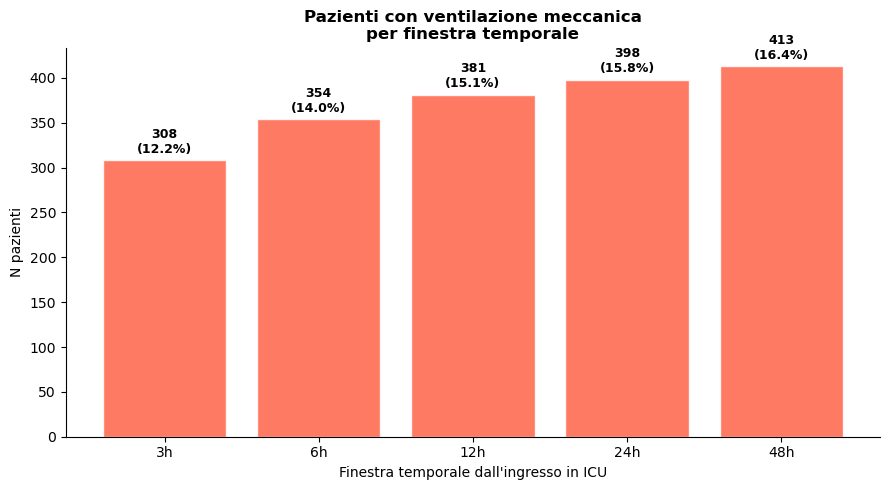

Totale pazienti con VM (qualsiasi momento): 436
Ventilati entro 48h:                        413
Ventilati DOPO 48h:                         23


In [10]:
#distribuzione delle versioni di mechanical ventilation, 3h, 6h, 12h, 24h, 48h
# Finestre temporali in minuti
finestre = {
    '3h':  3  * 60,
    '6h':  6  * 60,
    '12h': 12 * 60,
    '24h': 24 * 60,
    '48h': 48 * 60,
}

# Filtra solo mechanical ventilation
vm = df_t[df_t["treatmentstring"].str.contains(
    "mechanical ventilation", case=False, na=False
)]

# Conta pazienti unici per ogni finestra
counts = {}
for label, minuti in finestre.items():
    n = vm[vm["treatmentoffset"] <= minuti]["patientunitstayid"].nunique()
    counts[label] = n

print("Pazienti con VM per finestra temporale:")
for label, n in counts.items():
    print(f"  Entro {label}: {n} pazienti ({n/len(df_p)*100:.1f}%)")

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.keys(), counts.values(), 
              color='tomato', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df_p)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Finestra temporale dall\'ingresso in ICU')
ax.set_ylabel('N pazienti')
ax.set_title('Pazienti con ventilazione meccanica\nper finestra temporale',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('vm_finestre_temporali.png', dpi=150, bbox_inches='tight')
plt.show()

# Totale pazienti unici con VM in qualsiasi momento
totale_vm = vm["patientunitstayid"].nunique()
print(f"Totale pazienti con VM (qualsiasi momento): {totale_vm}")
print(f"Ventilati entro 48h:                        {counts['48h']}")
print(f"Ventilati DOPO 48h:                         {totale_vm - counts['48h']}")


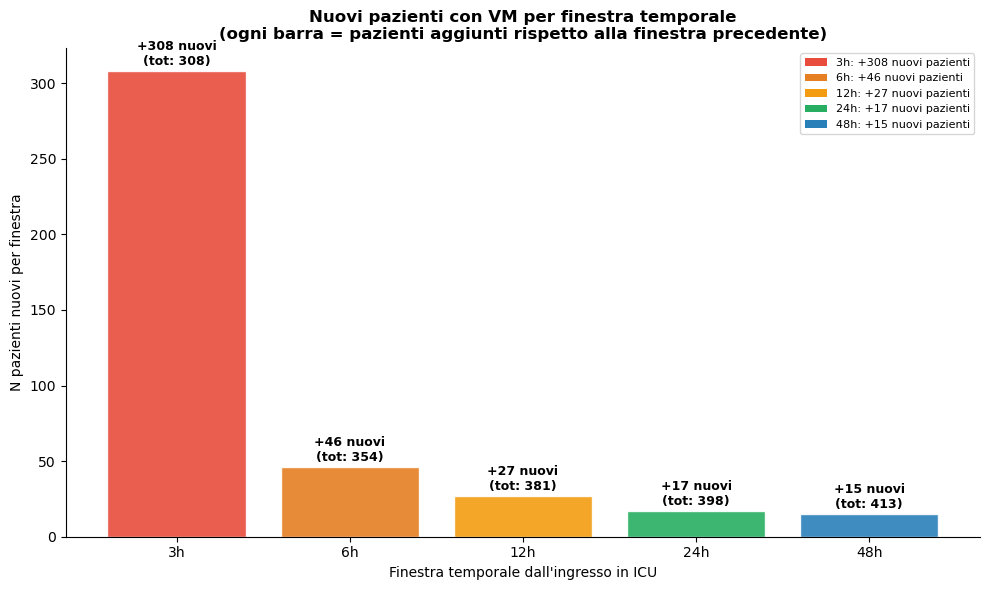

In [15]:
# Calcola pazienti NUOVI per ogni finestra (differenza)
labels = list(counts.keys())
values = list(counts.values())
nuovi = [values[0]] + [values[i] - values[i-1] for i in range(1, len(values))]

# Colori progressivi per finestra
colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2980b9']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, nuovi, color=colors, alpha=0.9, edgecolor='white')

for bar, nuovo, totale in zip(bars, nuovi, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'+{nuovo} nuovi\n(tot: {totale})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'{l}: +{n} nuovi pazienti')
                   for c, l, n in zip(colors, labels, nuovi)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

ax.set_xlabel("Finestra temporale dall'ingresso in ICU")
ax.set_ylabel('N pazienti nuovi per finestra')
ax.set_title('Nuovi pazienti con VM per finestra temporale\n'
             '(ogni barra = pazienti aggiunti rispetto alla finestra precedente)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('vm_finestre_nuovi.png', dpi=150, bbox_inches='tight')
plt.show()

Pazienti con VM per finestra temporale:
  Entro 3h: 308 pazienti (12.2%)
  Entro 6h: 354 pazienti (14.0%)
  Entro 12h: 381 pazienti (15.1%)
  Entro 24h: 398 pazienti (15.8%)
  Entro 48h: 413 pazienti (16.4%)

Totale pazienti con VM (qualsiasi momento): 436
Ventilati entro 48h:                        413
Ventilati DOPO 48h:                         23


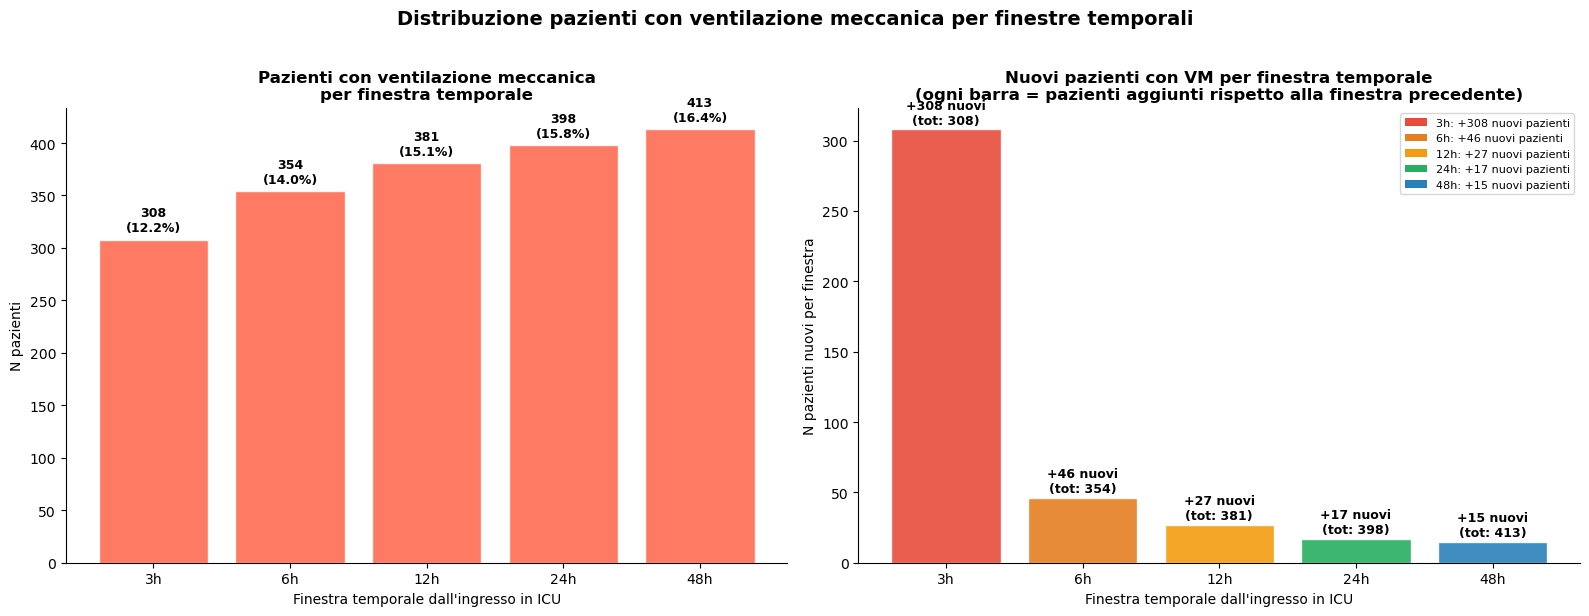

In [20]:
# Distribuzione delle versioni di mechanical ventilation, 3h, 6h, 12h, 24h, 48h
# Finestre temporali in minuti
finestre = {
    '3h':  3  * 60,
    '6h':  6  * 60,
    '12h': 12 * 60,
    '24h': 24 * 60,
    '48h': 48 * 60,
}

# Filtra solo mechanical ventilation
vm = df_t[df_t["treatmentstring"].str.contains(
    "mechanical ventilation", case=False, na=False
)]

# Conta pazienti unici per ogni finestra
counts = {}
for label, minuti in finestre.items():
    n = vm[vm["treatmentoffset"] <= minuti]["patientunitstayid"].nunique()
    counts[label] = n

print("Pazienti con VM per finestra temporale:")
for label, n in counts.items():
    print(f"  Entro {label}: {n} pazienti ({n/len(df_p)*100:.1f}%)")

# Totale pazienti unici con VM in qualsiasi momento
totale_vm = vm["patientunitstayid"].nunique()
print(f"\nTotale pazienti con VM (qualsiasi momento): {totale_vm}")
print(f"Ventilati entro 48h:                        {counts['48h']}")
print(f"Ventilati DOPO 48h:                         {totale_vm - counts['48h']}")

# Calcola pazienti NUOVI per ogni finestra (differenza)
labels = list(counts.keys())
values = list(counts.values())
nuovi = [values[0]] + [values[i] - values[i-1] for i in range(1, len(values))]

# GRAFICI AFFIANCATI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFICO 1: Distribuzione totale ---
bars1 = ax1.bar(labels, values, color='tomato', alpha=0.85, edgecolor='white')

for bar, val in zip(bars1, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df_p)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Finestra temporale dall\'ingresso in ICU')
ax1.set_ylabel('N pazienti')
ax1.set_title('Pazienti con ventilazione meccanica\nper finestra temporale',
             fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- GRAFICO 2: Nuovi pazienti per finestra ---
colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2980b9']
bars2 = ax2.bar(labels, nuovi, color=colors, alpha=0.9, edgecolor='white')

for bar, nuovo, totale in zip(bars2, nuovi, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'+{nuovo} nuovi\n(tot: {totale})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legenda per il secondo grafico
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'{l}: +{n} nuovi pazienti')
                   for c, l, n in zip(colors, labels, nuovi)]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8)

ax2.set_xlabel("Finestra temporale dall'ingresso in ICU")
ax2.set_ylabel('N pazienti nuovi per finestra')
ax2.set_title('Nuovi pazienti con VM per finestra temporale\n'
             '(ogni barra = pazienti aggiunti rispetto alla finestra precedente)',
             fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Aggiungi un titolo generale
fig.suptitle('Distribuzione pazienti con ventilazione meccanica per finestre temporali',
            fontweight='bold', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('vm_finestre_affiancate.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
FINESTRA = 1440  # minuti

df_p_filtered = df_p[df_p['unitdischargeoffset'] > FINESTRA].copy()

# Crea Y direttamente su df_p_filtered
df_p_filtered['Y'] = (df_p_filtered['unitdischargestatus'] == 'Expired').astype(int)
df_p['Y'] = (df_p['unitdischargestatus'] == 'Expired').astype(int)

print(f"Pazienti totali:                    {len(df_p)}")
print(f"Dimessi entro 24h (esclusi):        {len(df_p) - len(df_p_filtered)}")
print(f"Pazienti rimanenti:                 {len(df_p_filtered)}")
print(f"\nMortalità prima del filtro:  {df_p['Y'].mean()*100:.1f}%")
print(f"Mortalità dopo il filtro:    {df_p_filtered['Y'].mean()*100:.1f}%")


Pazienti totali:                    2520
Dimessi entro 24h (esclusi):        894
Pazienti rimanenti:                 1626

Mortalità prima del filtro:  5.0%
Mortalità dopo il filtro:    4.9%
